In [1]:
import os
import sys
sys.path.append(r"C:\root_v6.40.04\bin")
import uproot
import scienceplots
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
from pathlib import Path
from typing import Dict, List, Optional
from GeoModelSplitCal_Extraction_Classes import SimFileReader, ProcessHits, MIP_Calibration, ECAL_Resolution
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from iminuit import Minuit
from scipy.special import erf
from scipy.signal import fftconvolve
from scipy.interpolate import interp1d
import ROOT
import glob

c:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Python\GeoModelSplitCal_Extraction_Classes.py:99: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.vlines(x=105.658, ymin=0, ymax=2*10**5, colors='red', linestyles='--', label='$\mu^{-}$ mass')


In [2]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "font.family": "sans-serif",
})

Integrated energy = [110.7796175  108.50861488 112.61319801 ... 118.42296394 115.47659161
 204.56757637]
Fraction of original energy = [0.01107796 0.01085086 0.01126132 ... 0.0118423  0.01154766 0.02045676]


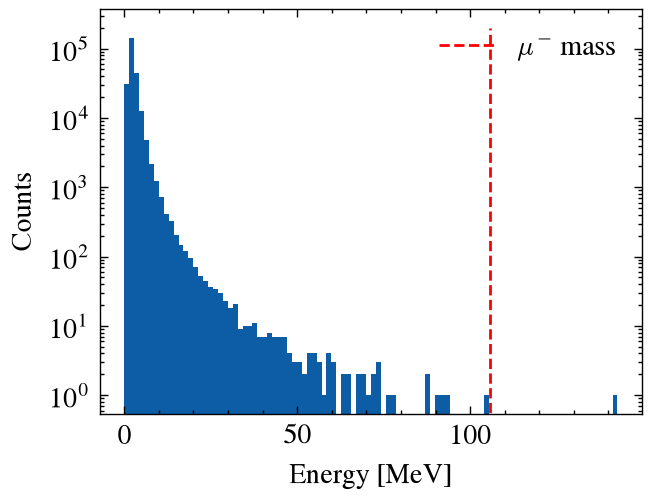

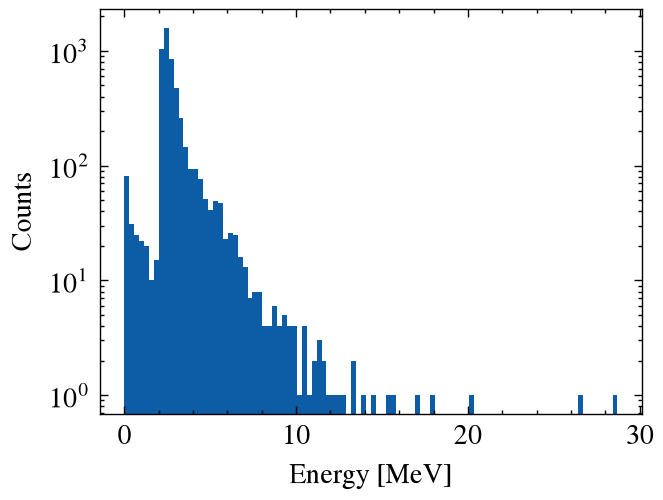

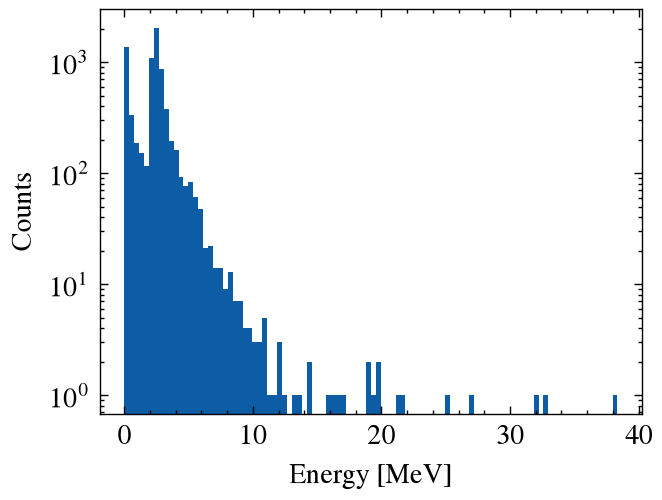

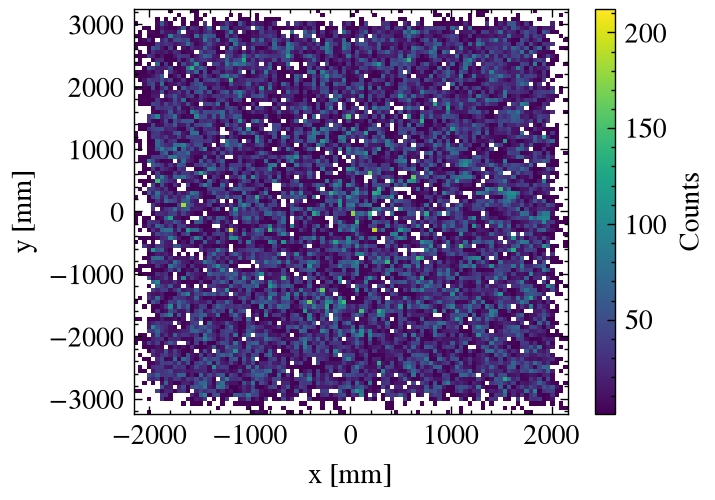

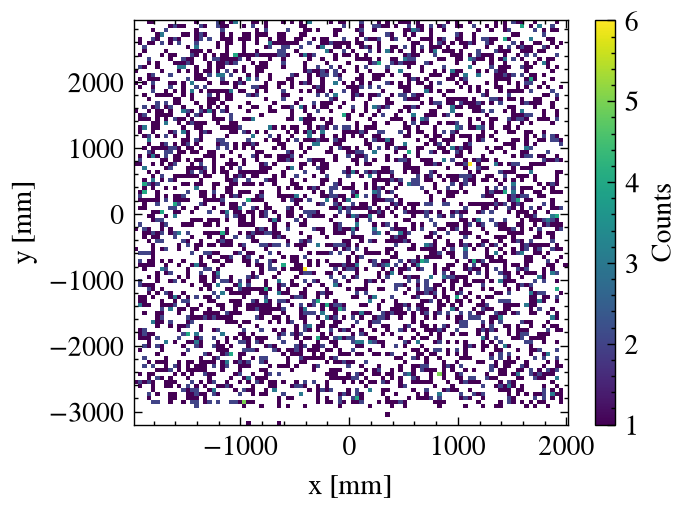

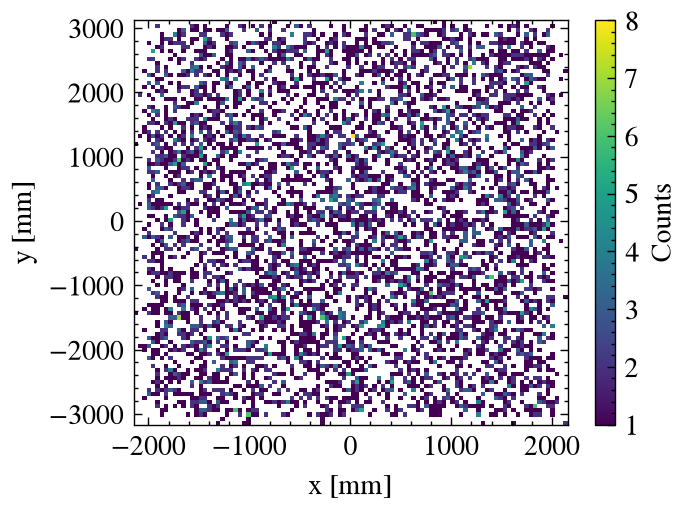

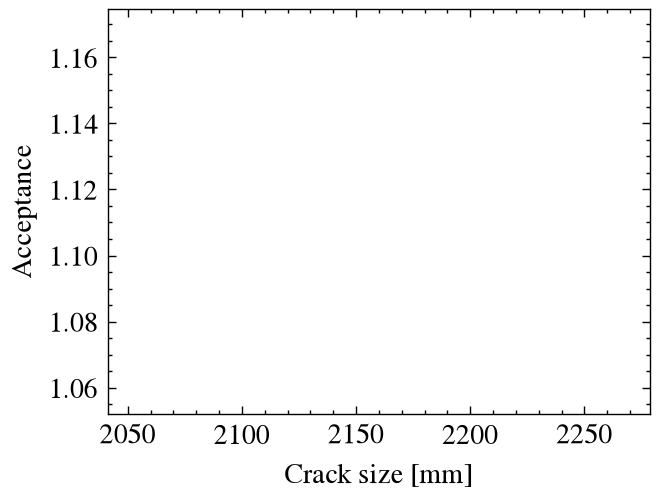

In [3]:

def main_exec():
    file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_Cracks_Gaussian"
    Sim = SimFileReader(os.path.join(file_path, "sim_mu-_10000MeV_2160mm.root"))

    branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
    edeps, x_globals, y_globals, z_globals, x_local, y_local, z_local, types = Sim.get_branches(branches)
    # print(f"Branches extracted: {branches}")
    # print(f"Number of events: {len(edeps)}")
    #print(f"Number of hits in first event: {len(edeps[1])}")
    # print(f"First event energy deposits: {edeps[1]}")
    # print(f"First event x hits: {x_globals[1]}")
    # print(f"First event y hits: {y_globals[1]}")
    # print(f"First event z hits: {z_globals[1]}")
    # print(f"First event layer types: {types[1]}")
    # print(f"Number of events after masking: {len(x_globals)}")
    # print(f"Number of events after masking: {len(x_globals[:][types == 1])}")
    # print(f"x hits in first layer across all events: {x_globals[:][types == 1]}")
    # zero_edeps = edeps[edeps == 0]
    # print(f"Zero energy points: {zero_edeps}")

    Sim.Diagnostic_Plotting(file_path)

if __name__ == "__main__":
    main_exec()


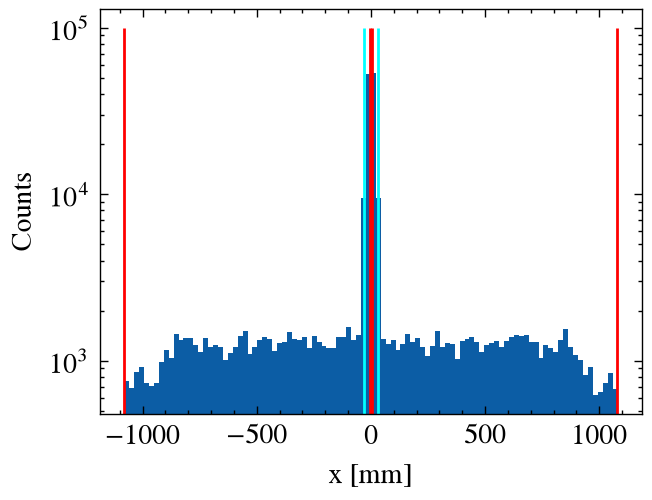

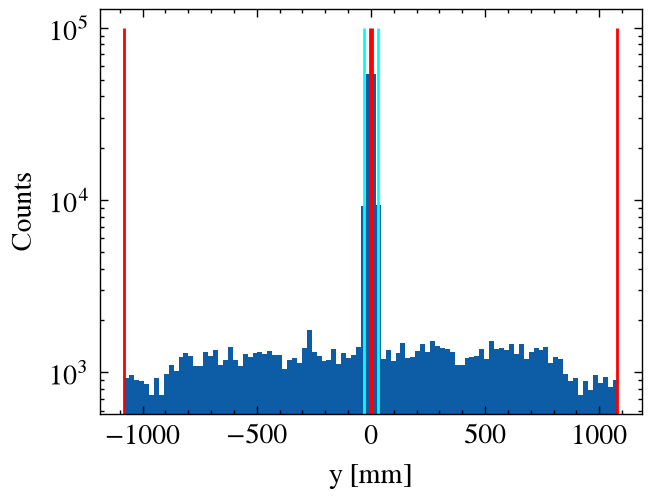

In [4]:
file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_Cracks_Gaussian"
Sim = SimFileReader(os.path.join(file_path, "sim_mu-_10000MeV_2160mm.root"))

branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
edeps, x_globals, y_globals, z_globals, x_locals, y_locals, z_locals, types = Sim.get_branches(branches)

#x and y local coordinates
with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(ak.flatten(x_locals), bins = 100)
    plt.vlines(x=[-1080, 1080], ymin=0, ymax=100000, colors='red')
    plt.vlines(x=[-30, 30], ymin=0, ymax=100000, colors='cyan')
    plt.vlines(x=[-5, 5], ymin=0, ymax=100000, colors='red')
    plt.xlabel("x [mm]")
    plt.ylabel("Counts")
    plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(ak.flatten(y_locals), bins = 100)
    plt.vlines(x=[-1080, 1080], ymin=0, ymax=100000, colors='red')
    plt.vlines(x=[-30, 30], ymin=0, ymax=100000, colors='cyan')
    plt.vlines(x=[-5, 5], ymin=0, ymax=100000, colors='red')
    plt.xlabel("y [mm]")
    plt.ylabel("Counts")
    plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

100
101
[1]
[1.93]
[1.93]


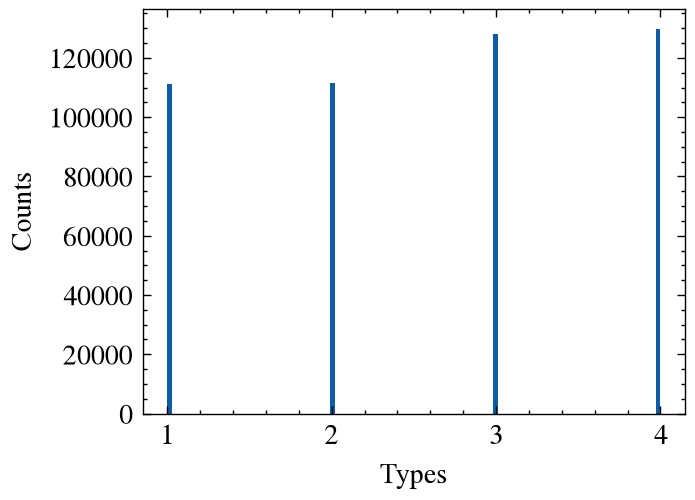

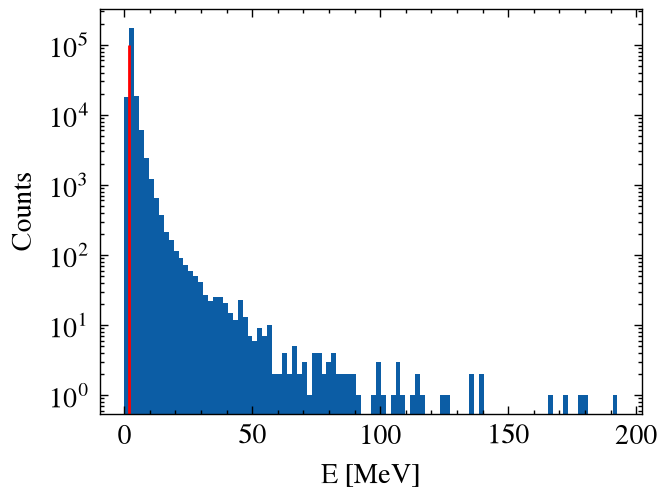

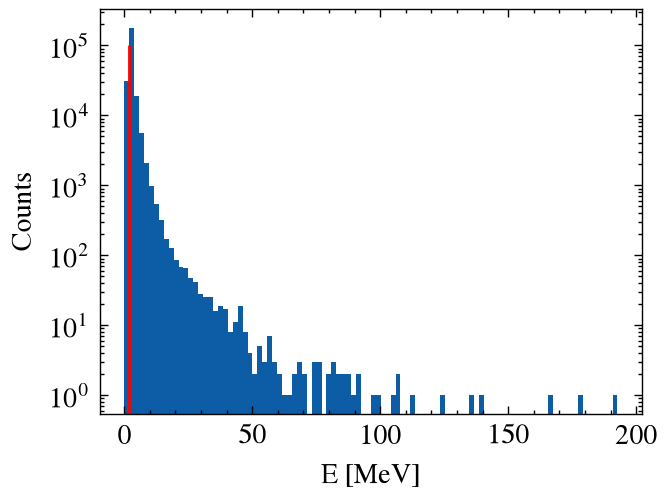

In [5]:
# MIP calibration

file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_MIP_Calibration"
Sim = SimFileReader(os.path.join(file_path, "sim_mu-_10000MeV_1000mm.root"))
branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
edeps, x_globals, y_globals, z_globals, x_locals, y_locals, z_locals, types = Sim.get_branches(branches)

edeps = ak.flatten(edeps)
types = ak.flatten(types)

edep_wide = edeps[(types == 1) | (types == 2)]

edep_thin = edeps[(types == 2) | (types == 3)]

wide_hist, wide_edge = np.histogram(edep_wide, bins=100)
thin_hist, thin_edge = np.histogram(edep_thin, bins=100)

print(len(thin_hist))
print(len(thin_edge))

peak_indices_wide, _ = find_peaks(wide_hist, height=10**5)
peak_indices_thin, _ = find_peaks(thin_hist, height=10**5)

print(peak_indices_thin)

edep_peak_wide = (wide_edge[peak_indices_wide + 1] + wide_edge[peak_indices_wide-1])/2
edep_peak_thin = (thin_edge[peak_indices_thin + 1] + thin_edge[peak_indices_thin-1])/2

print(edep_peak_wide)
print(edep_peak_thin)

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(types, bins = 100)
    plt.xlabel("Types")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_wide, bins = 100)
    plt.vlines(edep_peak_wide, ymin=0, ymax=100000, colors='red')
    plt.xlabel("E [MeV]")
    plt.ylabel("Counts")
    plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_thin, bins = 100)
    plt.vlines(edep_peak_thin, ymin=0, ymax=100000, colors='red')
    plt.xlabel("E [MeV]")
    plt.ylabel("Counts")
    plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

In [6]:
file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_MIP_Calibration"
MIP = MIP_Calibration(os.path.join(file_path, "sim_mu-_10000MeV_1000mm.root"))


results = MIP.perform_fit()
print(results)



MIP_1cm
Initial peak = 2.8897 MeV
Fit range    = 0.00 - 192.65 MeV

Running iminuit minimization...


c:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Python\GeoModelSplitCal_Extraction_Classes.py:99: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.vlines(x=105.658, ymin=0, ymax=2*10**5, colors='red', linestyles='--', label='$\mu^{-}$ mass')


KeyboardInterrupt: 

In [7]:
energies = np.array([5_000, 10_000, 20_000, 50_000, 100_000])

file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_ECAL_Resolution"
ECAL = ECAL_Resolution(file_path)



results = ECAL.perform_fit(energies)
print(results)

Not enough entries for Gaussian fit.
Not enough entries for Gaussian fit.
Not enough entries for Gaussian fit.
Not enough entries for Gaussian fit.
Not enough entries for Gaussian fit.


TypeError: 'NoneType' object is not subscriptable

In [ ]:
print(len(results))

2


In [ ]:
# --- Landau PDF (ROOT's TMath::Landau implementation) ---
def landau_pdf(x, mpv, sigma):
    """Approximate Landau density (ROOT convention)."""
    # ROOT uses a parametrized approximation; here's a common form
    # using the Moyal approximation as a stand-in.
    lam = (x - mpv) / sigma
    u = np.exp(-lam - np.exp(-lam))
    return u / sigma

def make_landau_gauss(mpv, landau_sigma, gauss_sigma, amp):
    grid = np.linspace(0, 200, 2000)
    landau = landau_pdf(grid, mpv, landau_sigma)
    gauss = np.exp(-0.5 * (grid/gauss_sigma)**2)
    conv = fftconvolve(landau, gauss, mode="same")
    conv /= conv.sum()
    f = interp1d(grid, amp * conv, kind="linear", bounds_error=False, fill_value=0)
    return f(x)


# --- Your data ---
x = (wide_edge[:-1] + wide_edge[1:]) / 2
x = np.array(x)
y = np.array(wide_hist)
print(wide_hist)
yerr = np.sqrt(y) + 1e-10  # Poisson errors

def landau_pdf(t, mpv, sigma):
    lam = (t - mpv) / sigma
    return np.exp(-lam - np.exp(-lam)) / sigma

def langauss(x, mpv, landau_sigma, gauss_sigma, amp):
    """Landau convolved with Gaussian resolution, evaluated at x."""
    # Fine grid spanning the data range
    grid = np.linspace(x.min() - 10*landau_sigma, x.max() + 10*landau_sigma, 2000)
    landau = landau_pdf(grid, mpv, landau_sigma)

    # Gaussian kernel
    gauss = np.exp(-0.5 * (grid / gauss_sigma)**2)

    # Convolve (FFT), normalize, interpolate back to x
    conv = fftconvolve(landau, gauss, mode="same")
    conv /= conv.sum()

    f = interp1d(grid, amp * conv, kind="linear", bounds_error=False, fill_value=0)
    return f(x)

# Cost function (chi-squared)
def chi2(mpv, landau_sigma, gauss_sigma, amp):
    model = langauss(x, mpv, landau_sigma, gauss_sigma, amp)
    return np.sum(((y - model) / yerr)**2)

# Minuit fit — give reasonable starting values
m = Minuit(chi2, mpv=50, landau_sigma=5, gauss_sigma=3, amp=y.max())
m.limits["landau_sigma"] = (0, None)
m.limits["gauss_sigma"] = (0, None)
m.limits["amp"] = (0, None)
m.errordef = Minuit.LEAST_SQUARES

m.migrad()
m.hesse()

print(m.values)   # fitted parameters
print(m.errors)   # uncertainties
print(m.fval)     # chi2

[17987, 174614, 18382, 5998, 2390, 1214, 653, 374, ..., 1, 1, 0, 0, 0, 0, 0, 1]


C:\Users\ewrightl\AppData\Local\Temp\ipykernel_25516\4152022137.py:42: RuntimeWarning: invalid value encountered in divide
  conv /= conv.sum()
C:\Users\ewrightl\AppData\Local\Temp\ipykernel_25516\4152022137.py:29: RuntimeWarning: overflow encountered in exp
  return np.exp(-lam - np.exp(-lam)) / sigma


<ValueView mpv=48.969245914715906 landau_sigma=4.924560735863172 gauss_sigma=2.8384311214789726 amp=154.08718539467213>
<ErrorView mpv=705.6221378170326 landau_sigma=5.775838937358162 gauss_sigma=430.974530761221 amp=8325.553236056909>
222713.9986826538


In [ ]:
# ============================================================
# Landau-Gaussian convolution
# ============================================================

def langaus_value(x, mpv, landau_sigma, gauss_sigma):

    if landau_sigma <= 0 or gauss_sigma <= 0:
        return 0.0

    xmin = x - 5.0 * gauss_sigma
    xmax = x + 5.0 * gauss_sigma

    nsteps = 200
    step = (xmax - xmin) / nsteps

    total = 0.0

    for i in range(nsteps):

        xx_landau = xmin + (i + 0.5) * step

        landau = ROOT.TMath.Landau(
            xx_landau,
            mpv,
            landau_sigma,
            True
        )

        gaussian = ROOT.TMath.Gaus(
            x,
            xx_landau,
            gauss_sigma,
            True
        )

        total += landau * gaussian

    return total * step


# ============================================================
# Fit
# ============================================================

def fit_mip(data, name, xmin, xmax):

    nbins = 100
    hist_min = 0.0
    hist_max = xmax

    hist = ROOT.TH1D(
        name,
        name,
        nbins,
        hist_min,
        hist_max
    )

    for value in data:
        hist.Fill(float(value))

    # --------------------------------------------------------
    # Fit bins strictly inside requested range
    # --------------------------------------------------------

    x_values = []
    counts = []

    bin_width = hist.GetBinWidth(1)

    for i in range(1, nbins + 1):

        x = hist.GetBinCenter(i)

        if x < xmin or x > xmax:
            continue

        y = hist.GetBinContent(i)

        if y <= 0:
            continue

        x_values.append(x)
        counts.append(y)

    x_values = np.asarray(x_values)
    counts = np.asarray(counts)

    # --------------------------------------------------------
    # Initial peak
    # --------------------------------------------------------

    peak_index = np.argmax(counts)
    peak = x_values[peak_index]
    max_content = counts[peak_index]

    print()
    print("======================================")
    print(name)
    print("======================================")
    print(f"Initial peak = {peak:.4f} MeV")
    print(f"Fit range    = {xmin:.2f} - {xmax:.2f} MeV")

    # --------------------------------------------------------
    # Model: expected histogram counts
    # --------------------------------------------------------

    def expected_counts(
        mpv,
        landau_sigma,
        gauss_sigma,
        amplitude
    ):

        values = []

        for x in x_values:

            convolution = langaus_value(
                x,
                mpv,
                landau_sigma,
                gauss_sigma
            )

            # convolution is a probability density.
            # Multiply by bin width to obtain probability
            # contained in the histogram bin.
            expected = (
                amplitude
                * convolution
                * bin_width
            )

            values.append(expected)

        return np.asarray(values)

    # --------------------------------------------------------
    # Extended Poisson negative log-likelihood
    # --------------------------------------------------------

    def nll(
        mpv,
        landau_sigma,
        gauss_sigma,
        amplitude
    ):

        expected = expected_counts(
            mpv,
            landau_sigma,
            gauss_sigma,
            amplitude
        )

        # Protect against numerical problems
        expected = np.maximum(expected, 1e-12)

        # Poisson deviance
        term = np.where(
            counts > 0,
            expected - counts + counts * np.log(counts / expected),
            expected
        )

        return 2.0 * np.sum(term)

    # --------------------------------------------------------
    # iminuit
    # --------------------------------------------------------

    m = Minuit(
        nll,
        mpv=peak,
        landau_sigma=0.2,
        gauss_sigma=0.3,
        amplitude=len(data)
    )

    m.limits["mpv"] = (1.8, 3.5)
    m.limits["landau_sigma"] = (0.05, 2.0)
    m.limits["gauss_sigma"] = (0.01, 1.0)
    m.limits["amplitude"] = (1.0, 1e7)

    # For -2 log likelihood
    m.errordef = Minuit.LIKELIHOOD

    print()
    print("Running iminuit minimization...")

    m.migrad()

    if not m.valid:
        print("WARNING: MIGRAD did not converge.")
        print(m.fmin)

    m.hesse()

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    mpv = m.values["mpv"]
    mpv_error = m.errors["mpv"]

    landau_sigma = m.values["landau_sigma"]
    gauss_sigma = m.values["gauss_sigma"]

    print()
    print(f"iminuit valid = {m.valid}")
    print(f"NLL/deviance   = {m.fval:.3f}")

    print()
    print(f"MPV            = {mpv:.6f} MeV")
    print(f"MPV error      = {mpv_error:.6f} MeV")
    print(f"Landau sigma   = {landau_sigma:.6f} MeV")
    print(f"Gaussian sigma = {gauss_sigma:.6f} MeV")
    print(f"Amplitude      = {m.values['amplitude']:.3f}")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    canvas = ROOT.TCanvas(
        "c_" + name,
        name,
        900,
        700
    )

    hist.GetXaxis().SetTitle(
        "Energy deposited per strip [MeV]"
    )

    hist.GetYaxis().SetTitle(
        "Entries"
    )

    hist.Draw()

    # ROOT function for visualisation only.
    # The minimisation itself was done by iminuit.

    def root_model(x, p):

        return (
            p[3]
            * langaus_value(
                x[0],
                p[0],
                p[1],
                p[2]
            )
            * bin_width
        )

    fit_func = ROOT.TF1(
        "fit_" + name,
        root_model,
        xmin,
        xmax,
        4
    )

    fit_func.SetParameters(
        mpv,
        landau_sigma,
        gauss_sigma,
        m.values["amplitude"]
    )

    fit_func.SetLineColor(ROOT.kRed)
    fit_func.Draw("same")

    canvas.SaveAs(
        rf"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution\{name}.png"
    )

    return mpv, mpv_error


# ============================================================
# Perform fits
# ============================================================

mip_1cm, err_1cm = fit_mip(
    edep_thin,
    "MIP_1cm",
    np.min(edep_thin),
    np.max(edep_thin)
)

mip_6cm, err_6cm = fit_mip(
    edep_wide,
    "MIP_6cm",
    np.min(edep_wide),
    np.max(edep_wide)
)


MIP_1cm
Initial peak = 2.8897 MeV
Fit range    = 0.00 - 192.65 MeV

Running iminuit minimization...


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_MIP_1cm
Info in <TCanvas::Print>: png file C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution\MIP_1cm.png has been created



iminuit valid = True
NLL/deviance   = 1797.915

MPV            = 2.360787 MeV
MPV error      = 0.003506 MeV
Landau sigma   = 0.129917 MeV
Gaussian sigma = 0.777662 MeV
Amplitude      = 238055.443

MIP_6cm
Initial peak = 2.8897 MeV
Fit range    = 0.00 - 192.65 MeV

Running iminuit minimization...


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_MIP_6cm
Info in <TCanvas::Print>: png file C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution\MIP_6cm.png has been created



iminuit valid = True
NLL/deviance   = 1665.317

MPV            = 2.401073 MeV
MPV error      = 0.004535 MeV
Landau sigma   = 0.157195 MeV
Gaussian sigma = 0.683448 MeV
Amplitude      = 217918.365


In [ ]:
MIP_1CM = mip_1cm
MIP_6CM = mip_6cm

print("======================================")
print("MIP CALIBRATION")
print("======================================")
print(f"1 cm strips = {MIP_1CM:.6f} MeV/MIP")
print(f"6 cm strips = {MIP_6CM:.6f} MeV/MIP")
print()


# ============================================================
# GAUSSIAN FIT WITH IMINUIT
# ============================================================

def gaussian_fit(data, beam_energy):

    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]

    if len(data) < 10:
        print("Not enough entries for Gaussian fit.")
        return None

    # Initial estimates
    mean0 = np.mean(data)
    sigma0 = np.std(data)

    # Restrict fit to a reasonable region around the response peak
    xmin = mean0 - 2.5 * sigma0
    xmax = mean0 + 2.5 * sigma0

    fit_data = data[(data >= xmin) & (data <= xmax)]

    if len(fit_data) < 10:
        print("Not enough entries inside Gaussian fit range.")
        return None

    # --------------------------------------------------------
    # Binned histogram
    # --------------------------------------------------------

    nbins = 100

    counts, edges = np.histogram(
        fit_data,
        bins=nbins,
        range=(xmin, xmax)
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = edges[1] - edges[0]

    # Poisson uncertainties
    errors = np.sqrt(counts.astype(float))

    # Avoid zero-error bins
    errors[errors == 0] = 1.0

    # --------------------------------------------------------
    # Gaussian model
    # --------------------------------------------------------

    def gaussian(x, amplitude, mean, sigma):

        return (
            amplitude
            * np.exp(-0.5 * ((x - mean) / sigma) ** 2)
        )

    # Model amplitude is counts per bin
    amplitude0 = np.max(counts)

    # --------------------------------------------------------
    # Chi-square function
    # --------------------------------------------------------

    def chi2(amplitude, mean, sigma):

        expected = gaussian(
            centers,
            amplitude,
            mean,
            sigma
        )

        return np.sum(
            ((counts - expected) / errors) ** 2
        )

    # --------------------------------------------------------
    # iminuit
    # --------------------------------------------------------

    m = Minuit(
        chi2,
        amplitude=amplitude0,
        mean=mean0,
        sigma=sigma0
    )

    m.errordef = Minuit.LEAST_SQUARES

    m.limits["amplitude"] = (0, None)
    m.limits["sigma"] = (1e-6, None)
    m.limits["mean"] = (xmin, xmax)

    print("Running iminuit Gaussian minimization...")

    m.migrad()
    m.hesse()

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    fitted_mean = m.values["mean"]
    fitted_sigma = abs(m.values["sigma"])

    mean_error = m.errors["mean"]
    sigma_error = m.errors["sigma"]

    resolution = fitted_sigma / fitted_mean
    resolution_percent = 100.0 * resolution

    chi2_value = m.fval
    ndof = len(counts) - 3

    print()
    print(f"iminuit valid       = {m.valid}")
    print(f"chi2                = {chi2_value:.3f}")
    print(f"ndof                = {ndof}")
    print(f"chi2/ndof           = {chi2_value / ndof:.3f}")
    print(f"Mean                = {fitted_mean:.6f} MIP")
    print(f"Mean error          = {mean_error:.6f} MIP")
    print(f"Sigma               = {fitted_sigma:.6f} MIP")
    print(f"Sigma error         = {sigma_error:.6f} MIP")
    print(f"Resolution sigma/mu = {resolution:.6f}")
    print(f"Resolution          = {resolution_percent:.3f} %")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    hist = ROOT.TH1D(
        f"h_{beam_energy}",
        f"{beam_energy} GeV electron response;Energy [MIP];Events",
        nbins,
        xmin,
        xmax
    )

    for value in fit_data:
        hist.Fill(float(value))

    canvas = ROOT.TCanvas(
        f"c_{beam_energy}",
        f"{beam_energy} GeV",
        900,
        700
    )

    hist.Draw("HIST")

    fit_function = ROOT.TF1(
        f"fit_{beam_energy}",
        "[0]*exp(-0.5*((x-[1])/[2])^2)",
        xmin,
        xmax
    )

    fit_function.SetParameters(
        m.values["amplitude"],
        fitted_mean,
        fitted_sigma
    )

    fit_function.SetLineWidth(2)
    fit_function.Draw("SAME")

    canvas.SaveAs(
        os.path.join(
            rf"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution",
            f"electron_response_{beam_energy}GeV.png"
        )
    )

    return {
        "energy_GeV": beam_energy,
        "mean_MIP": fitted_mean,
        "mean_error_MIP": mean_error,
        "sigma_MIP": fitted_sigma,
        "sigma_error_MIP": sigma_error,
        "resolution": resolution,
        "resolution_percent": resolution_percent,
        "chi2": chi2_value,
        "ndof": ndof,
        "fit_valid": m.valid,
        "entries": len(data)
    }



MIP CALIBRATION
1 cm strips = 2.360787 MeV/MIP
6 cm strips = 2.401073 MeV/MIP



In [ ]:
# Fractional resolution for 3 mm Pb

energies = np.array([5_000, 10_000, 20_000, 50_000, 100_000])

edep_sum_array = []

file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_ECAL_Resolution"

for energy in energies:
    Sim = SimFileReader(os.path.join(file_path, f"sim_mu-_{energy}MeV_1000mm.root"))
    branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
    edeps, x_globals, y_globals, z_globals, x_locals, y_locals, z_locals, types = Sim.get_branches(branches)

    edep_sum = [np.sum(edeps[i]) for i in range(len(edeps))]

    edep_sum_array.append(edep_sum)

edep_sum_array = np.array(edep_sum_array)

frac_resolutions = np.array([np.std(edep_sum_array[i])/np.mean(edep_sum_array[i]) for i in range(5)])


# Gaussian fit

results = []

for i in range(5):
    result = gaussian_fit(edep_sum_array[i], energies[i])
    results.append(result)

results = np.array(results)
#print(results)
resolutions = np.array(r["resolution"] for r in results)
print(resolutions)

Info in <TCanvas::Print>: png file C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution\electron_response_5000GeV.png has been created
Info in <TCanvas::Print>: png file C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution\electron_response_10000GeV.png has been created
Info in <TCanvas::Print>: png file C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution\electron_response_20000GeV.png has been created
Info in <TCanvas::Print>: png file C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution\electron_response_50000GeV.png has been created


Running iminuit Gaussian minimization...

iminuit valid       = True
chi2                = 97.007
ndof                = 97
chi2/ndof           = 1.000
Mean                = 1425.593393 MIP
Mean error          = 1.502775 MIP
Sigma               = 42.200509 MIP
Sigma error         = 1.220227 MIP
Resolution sigma/mu = 0.029602
Resolution          = 2.960 %
Running iminuit Gaussian minimization...

iminuit valid       = True
chi2                = 92.157
ndof                = 97
chi2/ndof           = 0.950
Mean                = 2865.593617 MIP
Mean error          = 2.024367 MIP
Sigma               = 57.955141 MIP
Sigma error         = 1.508701 MIP
Resolution sigma/mu = 0.020224
Resolution          = 2.022 %
Running iminuit Gaussian minimization...

iminuit valid       = True
chi2                = 81.875
ndof                = 97
chi2/ndof           = 0.844
Mean                = 5720.521080 MIP
Mean error          = 2.998258 MIP
Sigma               = 87.811358 MIP
Sigma error         = 2.2879

Info in <TCanvas::Print>: png file C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\ECAL_Simulation_Analysis\Figures\ECAL_Resolution\electron_response_100000GeV.png has been created


<generator object <genexpr> at 0x0000023531CA7B90>


In [ ]:
dtype = [
        ("energy_GeV", "f8"),
        ("mean_MIP", "f8"),
        ("mean_error_MIP", "f8"),
        ("sigma_MIP", "f8"),
        ("sigma_error_MIP", "f8"),
        ("resolution", "f8"),
        ("resolution_percent", "f8"),
        ("chi2", "f8"),
        ("ndof", "i4"),
        ("fit_valid", "?"),
        ("entries", "i4"),
    ]

output = np.array(
        [
            (
                r["energy_GeV"],
                r["mean_MIP"],
                r["mean_error_MIP"],
                r["sigma_MIP"],
                r["sigma_error_MIP"],
                r["resolution"],
                r["resolution_percent"],
                r["chi2"],
                r["ndof"],
                r["fit_valid"],
                r["entries"],
            )
            for r in results
        ],
        dtype=dtype
    )

output = np.array(output)
print(output['resolution'])
print(output[1])

[0.02960207 0.02022448 0.01535024 0.00997112 0.00769495]
(10000.0, 2865.5936172679717, 2.024366870094582, 57.955140783382944, 1.508701271456669, 0.02022447999400445, 2.022447999400445, 92.15679331581653, 97, True, 1000)


In [ ]:
def fractional_energy_resolution_fit(E, a, c):
    return np.sqrt(a**2/E + c**2)

def resolution_fit_error(E, a, c, cov_matrix):
    """
    Calculate propagated errors for risetime derived from radii.

    Parameters:
        E (array-like): Measured E.
        a, c (float): Fit parameters.
        cov_matrix (2D array): Covariance matrix for the fit parameters [a, c].

    Returns:
        tuple: frac_res propagated uncertainties.
    """
    errors = []
    for Ei in E:
        d_y_da = a/(Ei*np.sqrt((a**2/Ei) + c**2))
        d_y_dc = c/np.sqrt((a**2/Ei) + c**2)

        # Gradient vector
        gradient = np.array([d_y_da, d_y_dc])
        
        # Propagated variance
        sigma_y_squared = gradient @ cov_matrix @ gradient.T
        sigma_y = np.sqrt(sigma_y_squared)
        errors.append(sigma_y)
        
    return np.array(errors)

In [ ]:
frac_resolutions = output["resolution"]

print(frac_resolutions)

popt, pcov = curve_fit(fractional_energy_resolution_fit, energies, frac_resolutions)

a, c = popt

unc_params = np.sqrt(np.diag(pcov))

fitted_energies = np.linspace(10**3, 10**5, num=10**3)

fitted_frac_resolutions = fractional_energy_resolution_fit(fitted_energies, a, c)

frac_error = resolution_fit_error(energies, a, c, pcov)


[0.02960207 0.02022448 0.01535024 0.00997112 0.00769495]


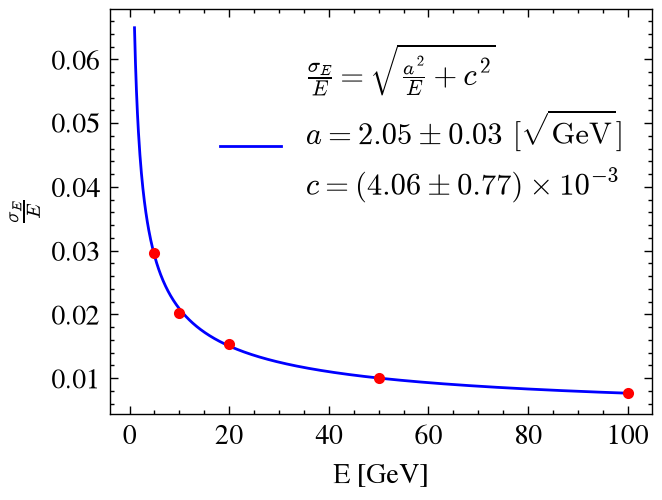

In [ ]:
legend_text = (
    r"$\frac{\sigma_E}{E} = \sqrt{\frac{a^2}{E} + c^2}$" "\n"
    rf"$a = {a:.2f} \pm {unc_params[0]:.2f} \ [\sqrt{{\text{{GeV}}}}]$" + "\n"
    rf"$c = ({10**3*c:.2f} \pm {10**3*unc_params[1]:.2f})\times 10^{{-3}}$" "\n"
)

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.errorbar(energies/10**3,frac_resolutions, yerr=frac_error, fmt='.', color='red', ecolor='black')
    plt.plot(fitted_energies/10**3, fitted_frac_resolutions, color='blue')
    plt.xlabel("E [GeV]")
    plt.ylabel(r"$\frac{\sigma_E}{E}$")
    plt.legend([legend_text], loc="best", prop={"family": "serif", "size": 11})
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

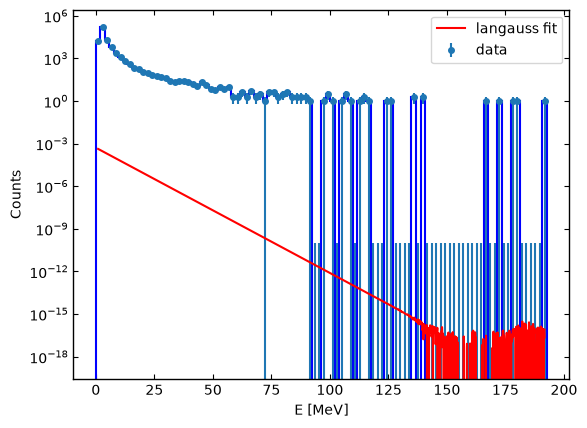

In [ ]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "font.family": "sans-serif",
})

plt.hist(edep_wide, bins = 100, histtype="step", color="blue", linewidth=1.5)
plt.errorbar(x, y, yerr=yerr, fmt="o", ms=4, label="data")
xmodel = np.linspace(x.min(), x.max(), 3000)
plt.plot(xmodel, langauss(xmodel, *[m.values[p] for p in m.parameters]), "r-", label="langauss fit")
plt.legend()
plt.xlabel("E [MeV]")
plt.ylabel("Counts")
plt.yscale("log")
plt.show()

In [ ]:
def fractional_energy_resolution_fit(E, a, c):
    return np.sqrt(a**2/E + c**2)

def resolution_fit_error(E, a, c, cov_matrix):
    """
    Calculate propagated errors for risetime derived from radii.

    Parameters:
        E (array-like): Measured E.
        a, c (float): Fit parameters.
        cov_matrix (2D array): Covariance matrix for the fit parameters [a, c].

    Returns:
        tuple: frac_res propagated uncertainties.
    """
    errors = []
    for Ei in E:
        d_y_da = a/(Ei*np.sqrt((a**2/Ei) + c**2))
        d_y_dc = c/np.sqrt((a**2/Ei) + c**2)

        # Gradient vector
        gradient = np.array([d_y_da, d_y_dc])
        
        # Propagated variance
        sigma_y_squared = gradient @ cov_matrix @ gradient.T
        sigma_y = np.sqrt(sigma_y_squared)
        errors.append(sigma_y)
        
    return np.array(errors)

[0.03255433 0.02266932 0.0193781  0.01580955 0.00972706]


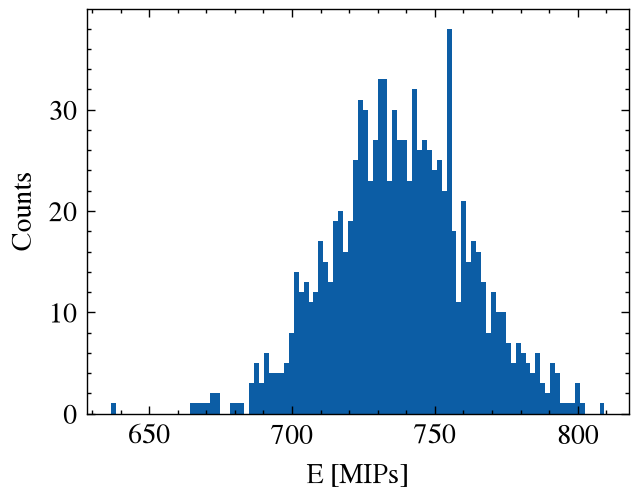

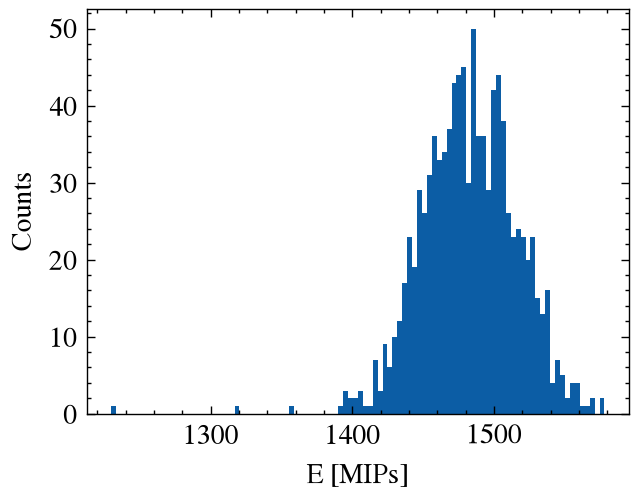

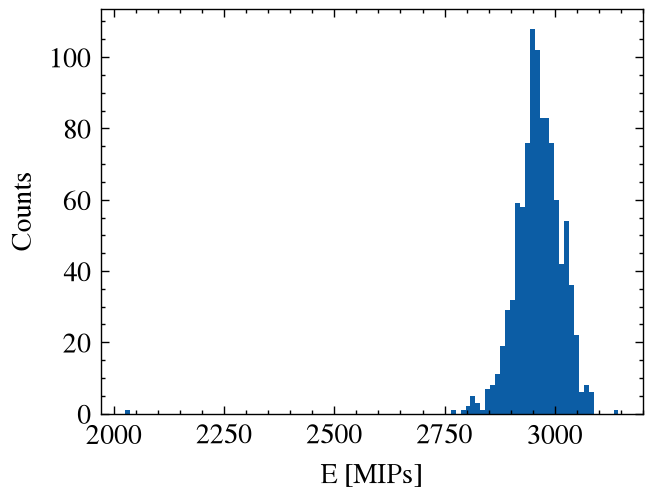

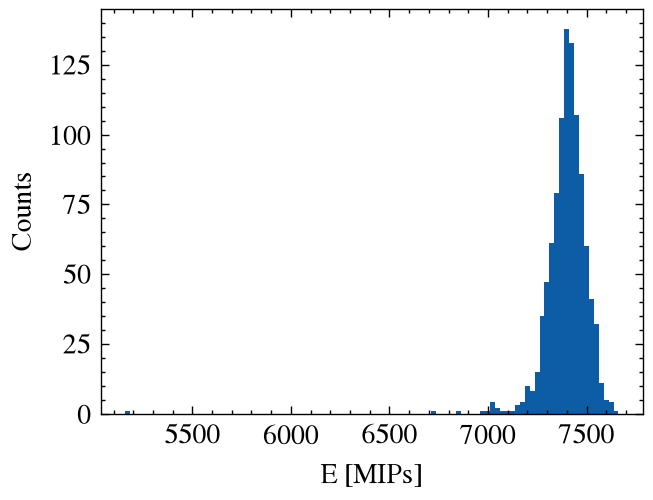

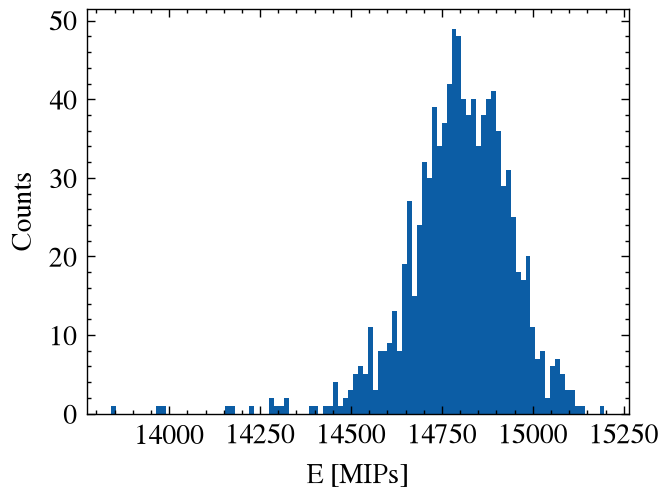

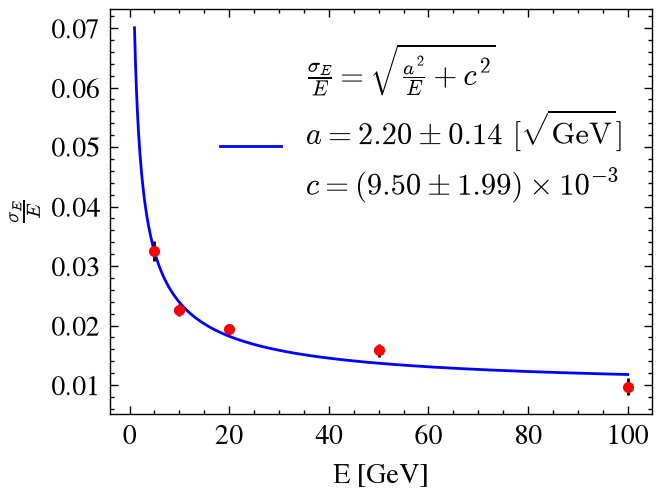

In [ ]:
# Fractional resolution for 3 mm Pb

energies = np.array([5_000, 10_000, 20_000, 50_000, 100_000])

edep_sum_array = []

file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_ECAL_Resolution"

for energy in energies:
    Sim = SimFileReader(os.path.join(file_path, f"sim_mu-_{energy}MeV_1000mm.root"))
    branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
    edeps, x_globals, y_globals, z_globals, x_locals, y_locals, z_locals, types = Sim.get_branches(branches)

    edep_sum = [np.sum(edeps[i]) for i in range(len(edeps))]

    edep_sum_array.append(edep_sum)

edep_sum_array = np.array(edep_sum_array)

frac_resolutions = np.array([np.std(edep_sum_array[i])/np.mean(edep_sum_array[i]) for i in range(5)])

#print(edep_sum_array)
print(frac_resolutions)

popt, pcov = curve_fit(fractional_energy_resolution_fit, energies, frac_resolutions)

a, c = popt

unc_params = np.sqrt(np.diag(pcov))

fitted_energies = np.linspace(10**3, 10**5, num=10**3)

fitted_frac_resolutions = fractional_energy_resolution_fit(fitted_energies, a, c)

frac_error = resolution_fit_error(energies, a, c, pcov)

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[0]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[1]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()


with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[2]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[3]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()


with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[4]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()


legend_text = (
    r"$\frac{\sigma_E}{E} = \sqrt{\frac{a^2}{E} + c^2}$" "\n"
    rf"$a = {a:.2f} \pm {unc_params[0]:.2f} \ [\sqrt{{\text{{GeV}}}}]$" + "\n"
    rf"$c = ({10**3*c:.2f} \pm {10**3*unc_params[1]:.2f})\times 10^{{-3}}$" "\n"
)

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.errorbar(energies/10**3,frac_resolutions, yerr=frac_error, fmt='.', color='red', ecolor='black')
    plt.plot(fitted_energies/10**3, fitted_frac_resolutions, color='blue')
    plt.xlabel("E [GeV]")
    plt.ylabel(r"$\frac{\sigma_E}{E}$")
    plt.legend([legend_text], loc="best", prop={"family": "serif", "size": 11})
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()